# Liquidh2o: Predictive Control of Water Tank Levels

### Liquidh2o: 

This notebook is part of the **Liquidh2o** project, which develops a predictive data analytics pipeline to monitor and control water distribution across client tanks.  
The objective is to ensure that each tank’s **predicted water level** closely matches the **measured level**, enabling automatic control and early detection of anomalies.

This is the first of several analyses within the Liquidh₂O project. In this case, we selected 13 tanks that share a specific characteristic: they are **supplied exclusively by the main distribution network**, without any additional water sources such as underground wells.  

These tanks provide a more stable and controlled behavior, making them ideal for developing and validating the predictive pipeline before extending it to more complex cases with mixed or independent supply systems.

#### Context
Each tank provides a time series of water levels measured every 30 minutes. These data reflect daily consumption and refill cycles, which vary by client and season.

#### Goal
Build and validate machine learning models that:
1. Predict short-term water levels based on past sensor data.  
2. Detect deviations between predicted and actual levels.  
3. Automate the validation process daily.

#### Approach
1. **Exploratory phase:** initial model prototyping with **PyCaret**, which selected a tree-based model as baseline.  
2. **Optimization phase:** migration to **LightGBM** to improve speed, interpretability, and scalability across all tanks.  
3. **Validation:** performance measured using **R²**, **MAE**, and **F1-score** for anomaly detection.  
4. **Automation:** integrated with SQL views and Python pipelines for daily retraining and validation.

---

*Note: All client data is confidential; only synthetic or anonymized samples are shown here.*



### Scope & Data Subset
This notebook is the **pilot (Phase 1)** of Liquidh₂O.  
It analyzes **13 tanks supplied exclusively by the main distribution network** to validate the approach before scaling.

**Data window:** limited, anonymized subset for demonstration.  
**Granularity:** 30-min level readings (`median_level`), plus calendar and weather features.


In [6]:
import sys, subprocess, importlib.metadata as meta
print("Kernel exe:", sys.executable)
subprocess.run([sys.executable, "-m", "pip", "show", "pycaret"])

Kernel exe: c:\Users\April Pc\AppData\Local\Programs\Python\Python311\python.exe


CompletedProcess(args=['c:\\Users\\April Pc\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', '-m', 'pip', 'show', 'pycaret'], returncode=0)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sqlalchemy import create_engine
import scipy.stats as stats
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
from scipy.stats import yeojohnson
pd.set_option("display.max_column", 100)
pd.set_option("display.max_rows", 200)
from sklearn.preprocessing import PowerTransformer
from pycaret.regression import setup, create_model, finalize_model, predict_model, plot_model, tune_model
import datetime

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sqlalchemy import create_engine

### Data Overview

The dataset contains time-series measurements from multiple client tanks.  
Each record represents the **median water level** for a specific time interval (30 min).  

Below is a short snapshot of the loaded dataset and a description of the main columns.


### Data Dictionary

| Column | Description | Example |
|:--------|:-------------|:---------|
| `tank_id` | Unique identifier of each client tank | 38 |
| `updated_at` | Timestamp of the measurement (30-min interval) | 2025-10-01 02:30 |
| `date` | Date extracted from `updated_at` | 2025-10-01 |
| `latitude`, `longitude` | Tank geographic coordinates | 10.52, –66.88 |
| `created_at` | Record creation timestamp (database field) | 2025-10-01 02:30 |
| `capacity` | Nominal storage capacity (liters or m³) | 12 000 |
| `version_controller` | Internal data version for traceability | 3 |
| `supplies` | Supply zone name | t1_norte |
| `water_network` | Distribution network the tank belongs to | red_central |
| `median_level` | Median water level at that timestamp | 3.47 |
| `slope_30` | 30-minute rate of change of the level | 0.12 |
| `tank_temp`, `tank_precip`, `tank_humidity` | Local weather features near the tank | 29.1 °C, 0.0 mm, 68 % |
| `dam_temp`, `dam_precip`, `dam_humidity` | Weather features at main dam or supply area | 28.7 °C, 0.2 mm, 72 % |
| `hour`, `minute` | Extracted temporal features | 2, 30 |
| `day_of_week`, `day_name` | Numeric and string representation of weekday | 3, Wednesday |
| `week_end` | Binary flag (1 = Saturday/Sunday) | 0 |
| `week`, `month`, `month_name`, `year` | Calendar features | 40, 10, October, 2025 |
| `early_morning`, `morning`, `afternoon`, `night` | One-hot encoded day-period indicators | 0/1 |
| `holiday` | Flag if the date was a public holiday | 0 |

*These features were engineered to capture temporal, spatial, and weather-driven patterns in tank behavior.*



### Loading  data
We are going to ingest the data from the table created in PostgreSQL

In [ ]:
# Building the connection URL. Conection info
pg_user     = os.getenv("pg_user", "postgres")
pg_password = os.getenv("pg_pasword", "****")
pg_host     = os.getenv("pg.host", "localhost")
pg_port     = os.getenv("pg_port", "5432")
pg_dbname   = os.getenv("pg_dbname", "liquido")

engine = create_engine(
    f"postgresql+psycopg2://{pg_user}:{pg_password}@{pg_host}:{pg_port}/{pg_dbname}")

In [8]:
df = pd.read_sql_table(
    "view_measurements_ml",
    con=engine,
    parse_dates=['updated_at'
                 ]
)

In [9]:
df= pd.read_sql_table("view_measurements_ml", con=engine)
df.head()

,tank_id,updated_at,date,latitude,longitude,created_at,max_level,capacity,version_controller,supplies,water_network,median_level,slope_30,tank_temp,tank_precip,tank_humidity,dam_temp,dam_precip,dam_humidity,hour,minute,day_of_week,day_name,week_end,week,month,month_name,year,early_morning,morning,afternoon,night,holiday
0,69,2024-03-14 19:30:00,2024-03-14,10.452063,-66.872348,2024-03-14 15:34:07,191.0,50000.0,15,t2,t2_sur,0.00,0,24.35,0.04,76.86,26.506667,0.016667,66.443334,19,30,4,Thu,0,11,3,Mar,2024,0,0,0,1,0
1,80,2024-03-23 16:00:00,2024-03-23,10.452075,-66.872368,2024-03-19 16:26:40,293.0,200000.0,9,t2,t2_sur,294.69,0,24.48,0.12,76.38,26.643333,0.050000,66.063332,16,0,6,Sat,1,12,3,Mar,2024,0,0,1,0,0
2,80,2024-03-23 16:30:00,2024-03-23,10.452075,-66.872368,2024-03-19 16:26:40,293.0,200000.0,9,t2,t2_sur,294.69,0,24.48,0.12,76.38,26.643333,0.050000,66.063332,16,30,6,Sat,1,12,3,Mar,2024,0,0,1,0,0
3,80,2024-03-23 18:30:00,2024-03-23,10.452075,-66.872368,2024-03-19 16:26:40,293.0,200000.0,9,t2,t2_sur,289.06,0,24.48,0.12,76.38,26.643333,0.050000,66.063332,18,30,6,Sat,1,12,3,Mar,2024,0,0,0,1,0
4,80,2024-03-23 19:00:00,2024-03-23,10.452075,-66.872368,2024-03-19 16:26:40,293.0,200000.0,9,t2,t2_sur,288.44,0,24.48,0.12,76.38,26.643333,0.050000,66.063332,19,0,6,Sat,1,12,3,Mar,2024,0,0,0,1,0


In [15]:
df.dtypes

tank_id                        int64
updated_at            datetime64[ns]
date                  datetime64[ns]
latitude                     float64
longitude                    float64
created_at            datetime64[ns]
capacity                     float64
version_controller             int64
supplies                      object
water_network                 object
median_level                 float64
slope_30                       int64
tank_temp                    float64
tank_precip                  float64
tank_humidity                float64
dam_temp                     float64
dam_precip                   float64
dam_humidity                 float64
hour                           int64
minute                         int64
day_of_week                    int64
day_name                      object
week_end                       int64
week                           int64
month                          int64
month_name                    object
year                           int64
e

## EDA

Lets see what does the data have to tell us. 

### Target

<Axes: >

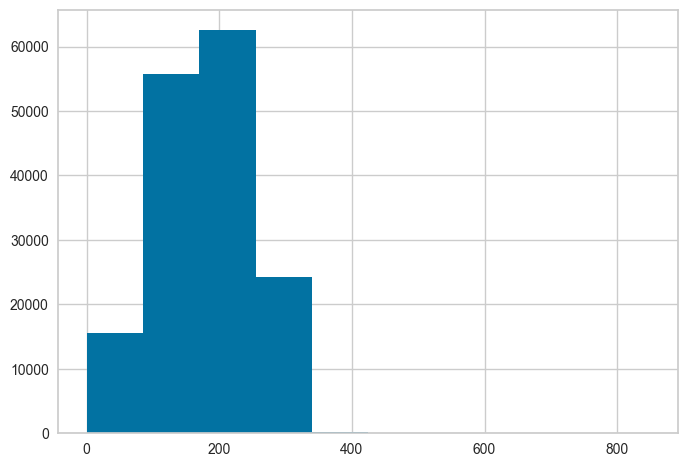

In [16]:
#Let's begin by exploring the target distribution.
df['median_level'].hist()

We can see that the target is continuous, and the distribution is skewed towards the right.

We are going to see the outliers, and what caused them.

In [17]:
over_350 = df[df['median_level']>=350]
print(len(over_350))
over_350['tank_id'].unique()

38


array([159, 200], dtype=int64)

In [18]:
over_350['tank_id'].nunique()

2

We have found out that those 30 rows have levels that are not accurated to the limit. So we are going to imputate them using winsorized.We have to impute this outliers, we are going to winsorize them by tank 

In [19]:
len(over_350)

38

We have some outliers that we have to correct. Those outliers are bad reading, so we are going to windsorized using the cap

In [20]:
# 1) Make your “winsorized” column default to the original
df['median_level_wins'] = df['median_level']

# 2) Build a mask that picks exactly the 38 rows you want to cap
mask = (
    df['tank_id'].isin([159, 200])        # only those two tanks
    & (df['median_level'] > 350)         # only readings above 350
)

# 3) Look at how many rows that is
print("Rows to cap:", mask.sum())  # should be ~38

# 4) Cap them in place
df.loc[mask, 'median_level_wins'] = 350

# 5) verify no others changed
changed = (df['median_level'] != df['median_level_wins']).sum()
print("Total capped rows:", changed)  # should match mask.sum()


Rows to cap: 38
Total capped rows: 38


In [21]:
df.head()

,tank_id,updated_at,date,latitude,longitude,created_at,capacity,version_controller,supplies,water_network,median_level,slope_30,tank_temp,tank_precip,tank_humidity,dam_temp,dam_precip,dam_humidity,hour,minute,day_of_week,day_name,week_end,week,month,month_name,year,early_morning,morning,afternoon,night,holiday,median_level_wins
0,69,2024-03-14 19:30:00,2024-03-14,10.452063,-66.872348,2024-03-14 15:34:07,50000.0,15,t2,t2_sur,0.00,0,24.35,0.04,76.86,26.506667,0.016667,66.443334,19,30,4,Thu,0,11,3,Mar,2024,0,0,0,1,0,0.00
1,80,2024-03-19 16:30:00,2024-03-19,10.452075,-66.872368,2024-03-19 16:26:40,200000.0,9,t2,t2_sur,0.00,-1,25.44,0.01,72.17,27.430000,0.026667,62.676666,16,30,2,Tue,0,12,3,Mar,2024,0,0,1,0,0,0.00
2,80,2024-03-19 17:00:00,2024-03-19,10.452075,-66.872368,2024-03-19 16:26:40,200000.0,9,t2,t2_sur,0.00,0,25.44,0.01,72.17,27.430000,0.026667,62.676666,17,0,2,Tue,0,12,3,Mar,2024,0,0,1,0,0,0.00
3,80,2024-03-21 17:00:00,2024-03-21,10.452075,-66.872368,2024-03-19 16:26:40,200000.0,9,t2,t2_sur,292.81,-1,24.34,0.02,77.21,26.526667,0.013333,67.023335,17,0,4,Thu,0,12,3,Mar,2024,0,0,1,0,0,292.81
4,80,2024-03-21 17:30:00,2024-03-21,10.452075,-66.872368,2024-03-19 16:26:40,200000.0,9,t2,t2_sur,294.06,1,24.34,0.02,77.21,26.526667,0.013333,67.023335,17,30,4,Thu,0,12,3,Mar,2024,0,0,1,0,0,294.06


<Axes: >

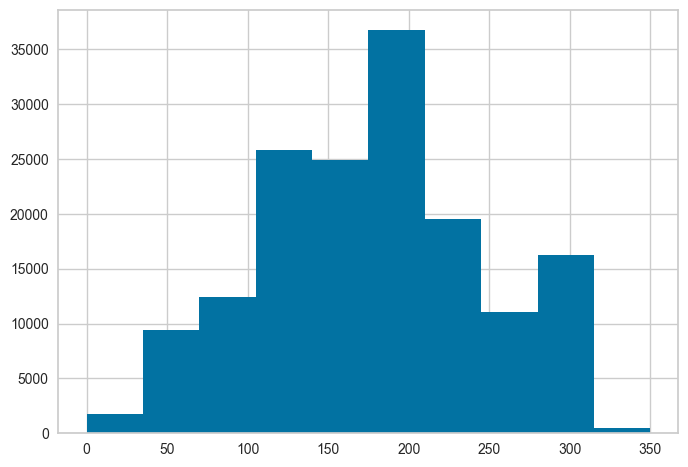

In [22]:
df['median_level_wins'].hist()

It looks more gaussians. We are going to sustitute the median_level outliers with the new ones.

In [23]:
# 1) Overwrite the original target
df['median_level'] = df['median_level_wins']

# 2) Drop the helper column
df.drop(columns='median_level_wins', inplace=True)


### Variable types

In [24]:
# let's identify the categorical variables
# we will capture those of type *object*

cat_var = [var for var in df.columns if df[var].dtype == "O" ]

In [25]:
# Numeric level
num_var = [var for var in df.columns if var not in cat_var and var!= 'median_level']
len(num_var)

27

### Missing values

Let's go ahead and find out which variables of the dataset contain missing values.

In [26]:
missing_values = [var for var in df.columns if df[var].isnull().sum()>0]
df[missing_values].isnull().mean()

Series([], dtype: float64)

There few missing values, later on we are going to decide what to do with them. Probably drop them.

### Numerical variables

Let's go ahead and find out what numerical variables we have in the dataset

In [27]:
print(f'Number of numerical variables in dataset:', len(num_var))
df[num_var].head()

Number of numerical variables in dataset: 27


,tank_id,updated_at,date,latitude,longitude,created_at,capacity,version_controller,slope_30,tank_temp,tank_precip,tank_humidity,dam_temp,dam_precip,dam_humidity,hour,minute,day_of_week,week_end,week,month,year,early_morning,morning,afternoon,night,holiday
0,69,2024-03-14 19:30:00,2024-03-14,10.452063,-66.872348,2024-03-14 15:34:07,50000.0,15,0,24.35,0.04,76.86,26.506667,0.016667,66.443334,19,30,4,0,11,3,2024,0,0,0,1,0
1,80,2024-03-19 16:30:00,2024-03-19,10.452075,-66.872368,2024-03-19 16:26:40,200000.0,9,-1,25.44,0.01,72.17,27.430000,0.026667,62.676666,16,30,2,0,12,3,2024,0,0,1,0,0
2,80,2024-03-19 17:00:00,2024-03-19,10.452075,-66.872368,2024-03-19 16:26:40,200000.0,9,0,25.44,0.01,72.17,27.430000,0.026667,62.676666,17,0,2,0,12,3,2024,0,0,1,0,0
3,80,2024-03-21 17:00:00,2024-03-21,10.452075,-66.872368,2024-03-19 16:26:40,200000.0,9,-1,24.34,0.02,77.21,26.526667,0.013333,67.023335,17,0,4,0,12,3,2024,0,0,1,0,0
4,80,2024-03-21 17:30:00,2024-03-21,10.452075,-66.872368,2024-03-19 16:26:40,200000.0,9,1,24.34,0.02,77.21,26.526667,0.013333,67.023335,17,30,4,0,12,3,2024,0,0,1,0,0


#### Temporal variables

We have 4 temporal variables in the dataset:

-updated_at_30

-date

-created_at

In [28]:
temp_var = [var for var in num_var if df[var].dtype =='datetime64[ns]']

In [29]:
df[temp_var].head()

,updated_at,date,created_at
0,2024-03-14 19:30:00,2024-03-14,2024-03-14 15:34:07
1,2024-03-19 16:30:00,2024-03-19,2024-03-19 16:26:40
2,2024-03-19 17:00:00,2024-03-19,2024-03-19 16:26:40
3,2024-03-21 17:00:00,2024-03-21,2024-03-19 16:26:40
4,2024-03-21 17:30:00,2024-03-21,2024-03-19 16:26:40


Text(0, 0.5, 'Median Level')

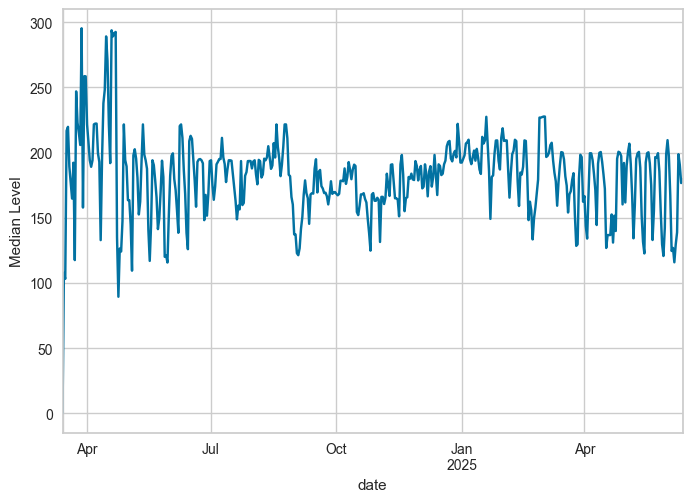

In [30]:
#Lets see if we can find any relationship between temporal variables and the target

df.groupby('date')['median_level'].median().plot()
plt.ylabel('Median Level')

We can thing thar the reading of April-MAy 2024 weren't that clean and to few, but after June 2023 we can see a more stable reading. We can see that from September to January the tank's level is more unstable. 

# Discrete variables
Let's go ahead and find discrete variables

In [ ]:
disc_var = [var for var in num_var if len(df[var].unique())<=10 and var not in temp_var]
print(f'The number of disc_var is', len(disc_var))

In [34]:
df[disc_var].head()

,version_controller,slope_30,minute,day_of_week,week_end,year,early_morning,morning,afternoon,night,holiday
0,15,0,30,4,0,2024,0,0,0,1,0
1,9,-1,30,2,0,2024,0,0,1,0,0
2,9,0,0,2,0,2024,0,0,1,0,0
3,9,-1,0,4,0,2024,0,0,1,0,0
4,9,1,30,4,0,2024,0,0,1,0,0


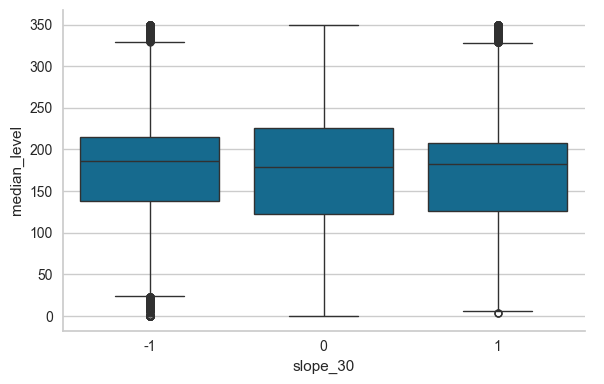

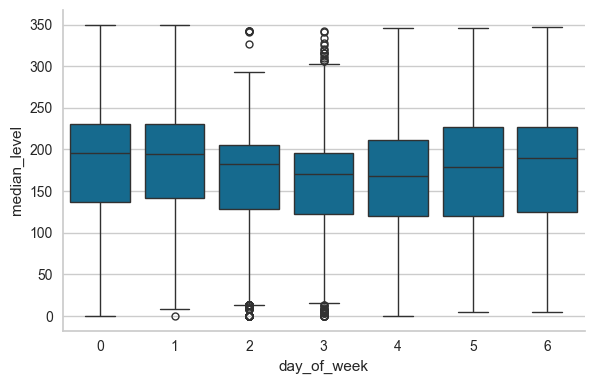

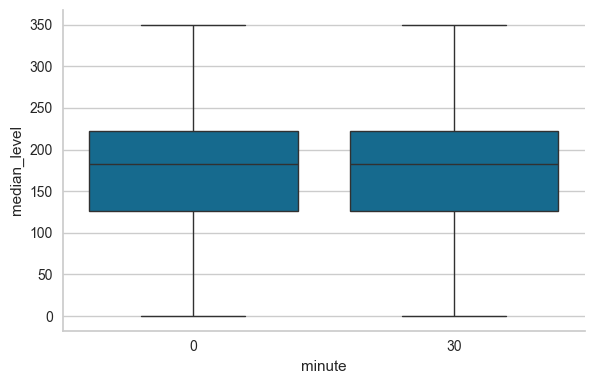

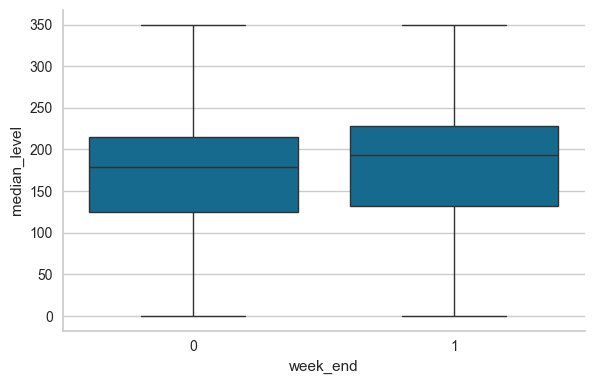

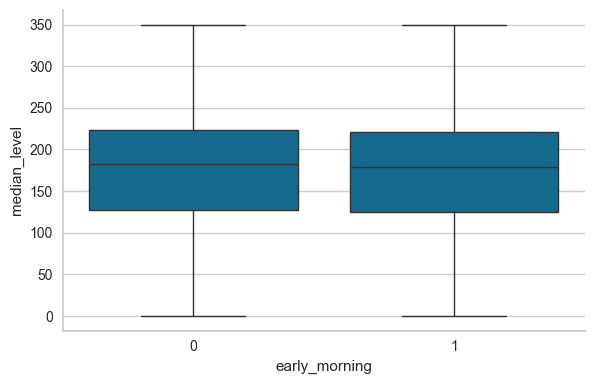

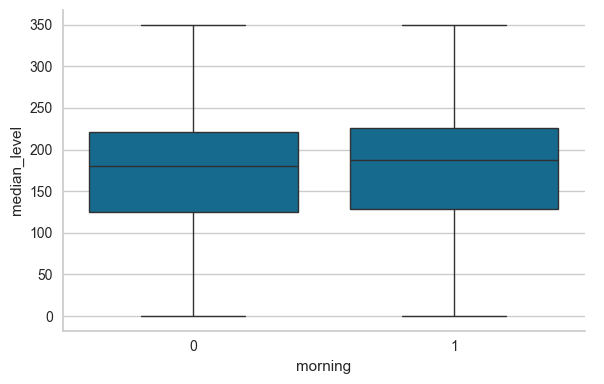

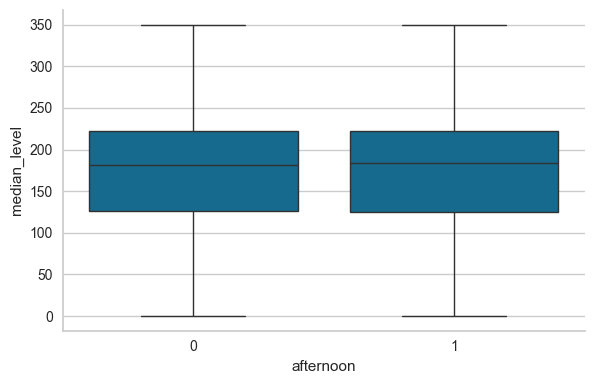

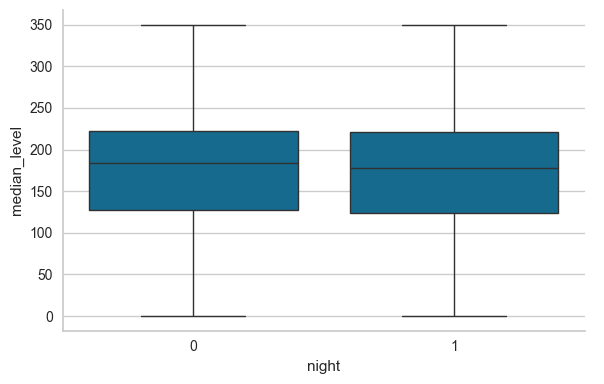

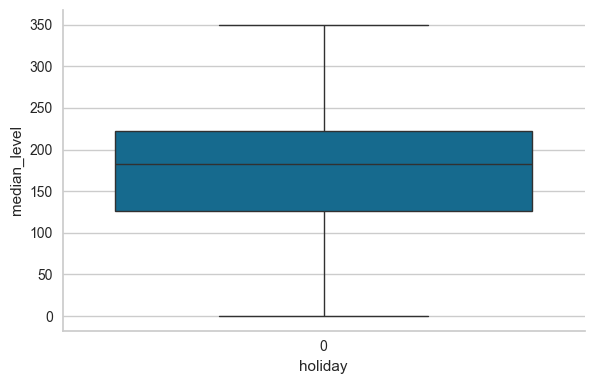

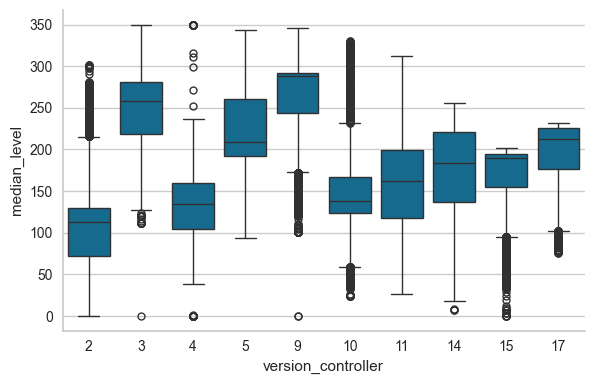

In [35]:
for var in ['slope_30', 'day_of_week','minute', 'week_end', 'early_morning','morning','afternoon','night','holiday', 'version_controller']:
    #Make a plot with Catplot
    sns.catplot(x=var, y='median_level', data=df, kind='box', height=4, aspect=1.5)
    plt.show()
   

For most discrete numerical variables, we don't see any increase in the level,  so we can't see any tendency with them most likely those variables are bit a good predictor of tank level

We see a discrete increase in the water levels  with the day_of_the_week and weekend and inderesting plot in version_controler. 



### Continuous Variable


Let's go ahead and find the distribution of the continuous variables. We will consider continuous variables to all those that are not temporal or discrete.


In [36]:
cont_var = [var for var in num_var if var not in temp_var + disc_var]
print(f'There are', len(cont_var), 'continuous variables in the data')

There are 13 continuous variables in the data


In [37]:
df[cont_var].head()

,tank_id,latitude,longitude,capacity,tank_temp,tank_precip,tank_humidity,dam_temp,dam_precip,dam_humidity,hour,week,month
0,69,10.452063,-66.872348,50000.0,24.35,0.04,76.86,26.506667,0.016667,66.443334,19,11,3
1,80,10.452075,-66.872368,200000.0,25.44,0.01,72.17,27.430000,0.026667,62.676666,16,12,3
2,80,10.452075,-66.872368,200000.0,25.44,0.01,72.17,27.430000,0.026667,62.676666,17,12,3
3,80,10.452075,-66.872368,200000.0,24.34,0.02,77.21,26.526667,0.013333,67.023335,17,12,3
4,80,10.452075,-66.872368,200000.0,24.34,0.02,77.21,26.526667,0.013333,67.023335,17,12,3


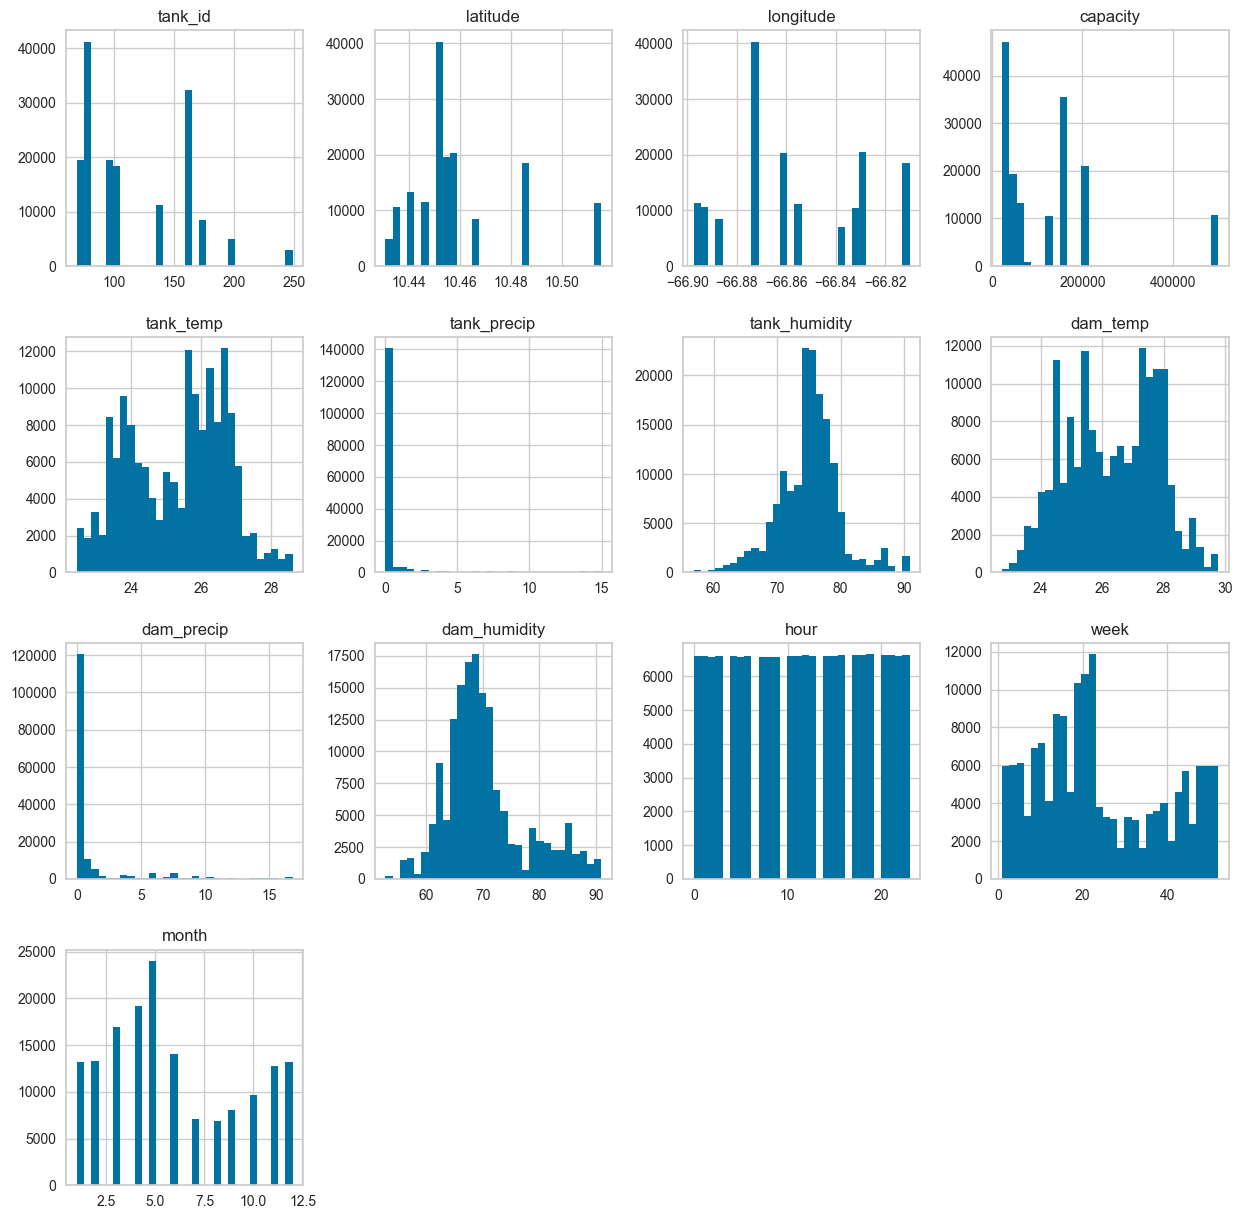

In [38]:
# lets plot histograms for all continuous variables
df[cont_var].hist(bins=30, figsize=(15,15))
plt.show()


The variables are not normally distributed. And there are a particular few that are extremely skewed like dam_preci, and takn precipitation.

We are going to apply the Yeo-Johnson  or log transformation to tank_temp and dam_temp to see if we can improve them and create a binay for both tank_preci and dam_preci

Let's go ahead and do that.

In [39]:
#Lets make a list with the super screw plots 

super_screwed = ['tank_precip','dam_precip']

In [40]:
cont_vars = [var for var in cont_var if var not in  super_screwed]

### Yeo Johson Transformation

In [41]:
cont_vars

['tank_id',
 'latitude',
 'longitude',
 'capacity',
 'tank_temp',
 'tank_humidity',
 'dam_temp',
 'dam_humidity',
 'hour',
 'week',
 'month']

array([[<Axes: title={'center': 'tank_temp'}>,
        <Axes: title={'center': 'tank_humidity'}>],
       [<Axes: title={'center': 'dam_temp'}>,
        <Axes: title={'center': 'dam_humidity'}>]], dtype=object)

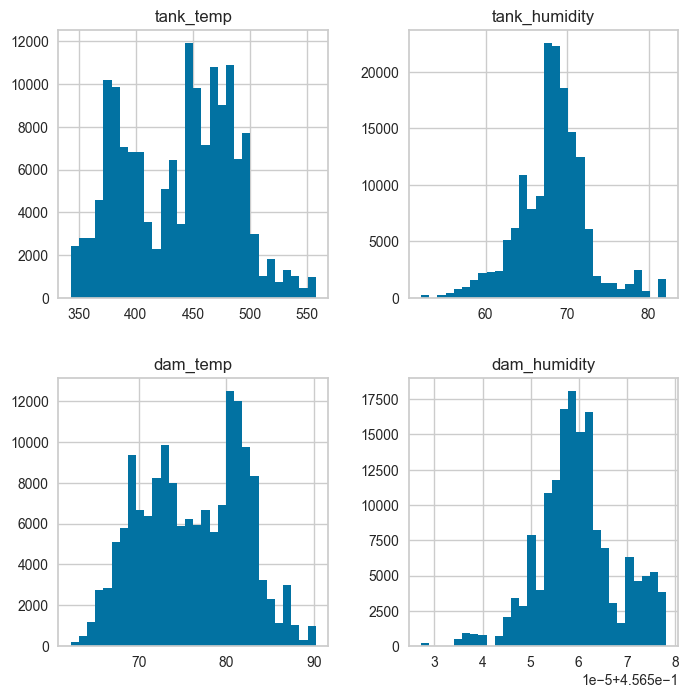

In [42]:
temp = df.copy()
curve_change = ['tank_temp', 'tank_humidity', 'dam_temp', 'dam_humidity']

for var in curve_change:
    temp[var], param = stats.yeojohnson(df[var])

temp[curve_change].hist(bins=30, figsize=(8,8))
    

It seems that there is no su much change. Lets try with log

### Log Transfomation

array([[<Axes: title={'center': 'tank_temp'}>,
        <Axes: title={'center': 'tank_humidity'}>],
       [<Axes: title={'center': 'dam_temp'}>,
        <Axes: title={'center': 'dam_humidity'}>]], dtype=object)

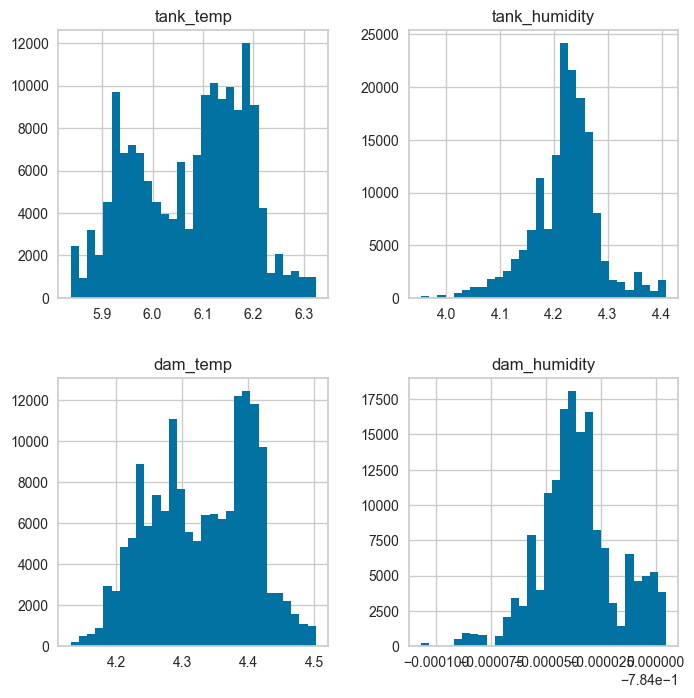

In [43]:
# We are going to apply the log transfomation only for some variables as tank temperature, tank humidity, dam temperature and dam humidity

for var in curve_change:
    temp[var]= np.log(temp[var])

temp[curve_change].hist(bins=30, figsize=(8,8))

The changes in both transformation respect to the original is almost imperceptive.

Whether this could helps improve the predictive power, remains to be seen.

Here, we will do a quick visual exploration here:

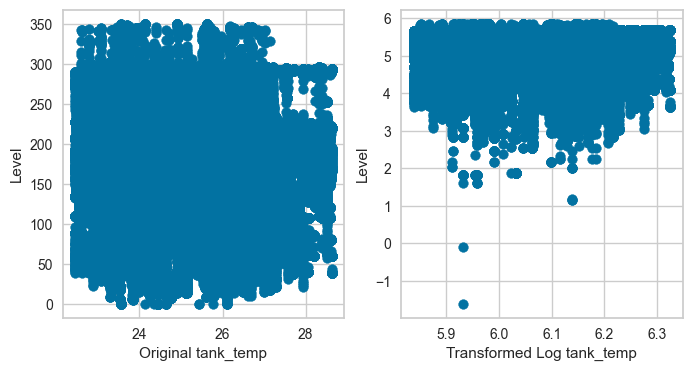

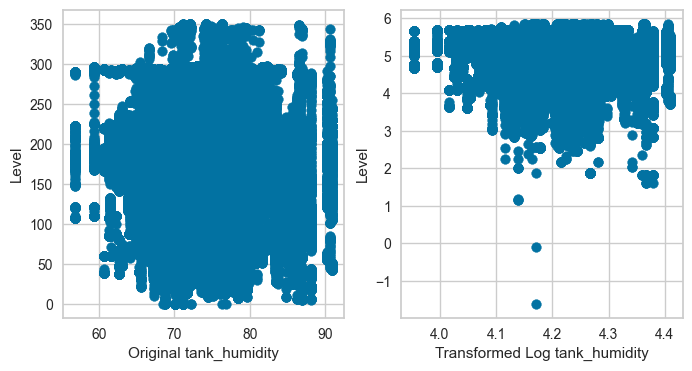

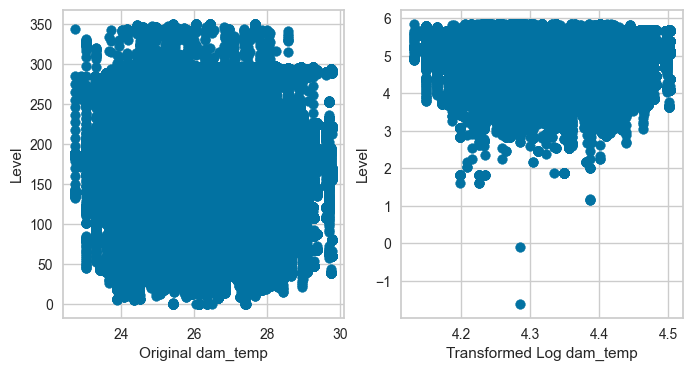

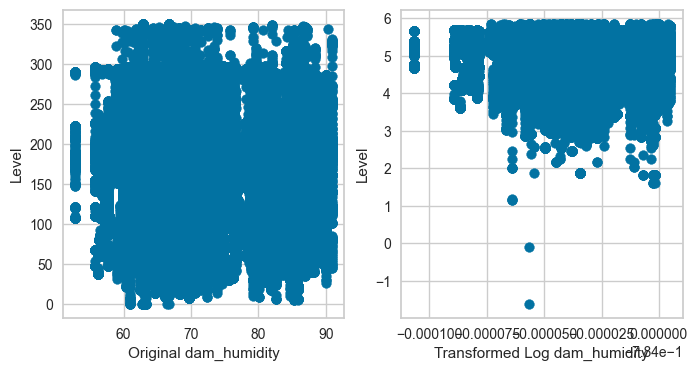

In [44]:

for var in curve_change:
    
    plt.figure(figsize=(8,4))
    
    # plot the original variable vs sale price    
    plt.subplot(1, 2, 1)
    plt.scatter(df[var], (df['median_level']))
    plt.ylabel('Level')
    plt.xlabel('Original ' + var)

    # plot transformed variable vs sale price
    plt.subplot(1, 2, 2)
    plt.scatter(temp[var], np.log(temp['median_level']))
    plt.ylabel('Level')
    plt.xlabel('Transformed Log ' + var)
                
    plt.show()

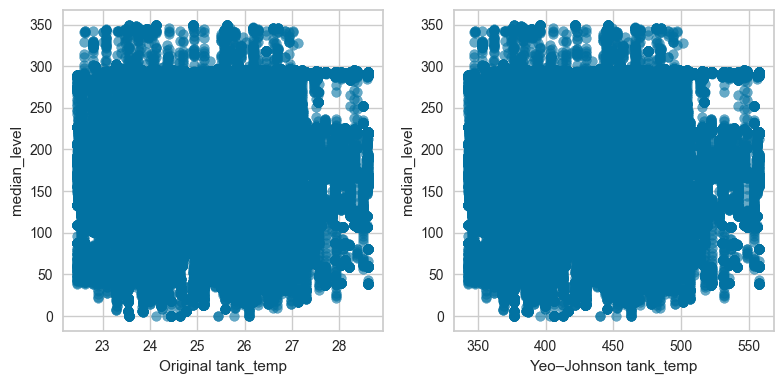

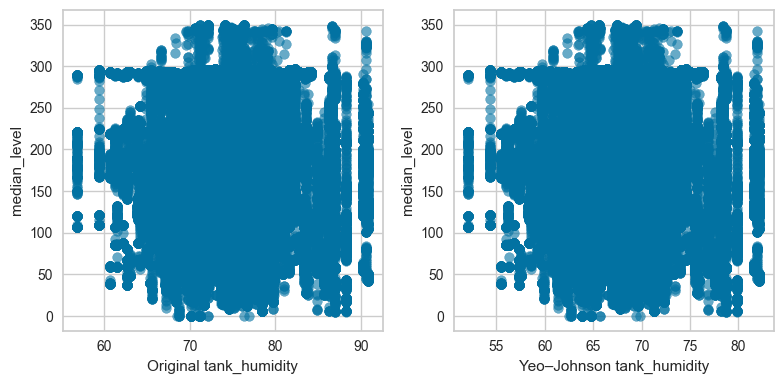

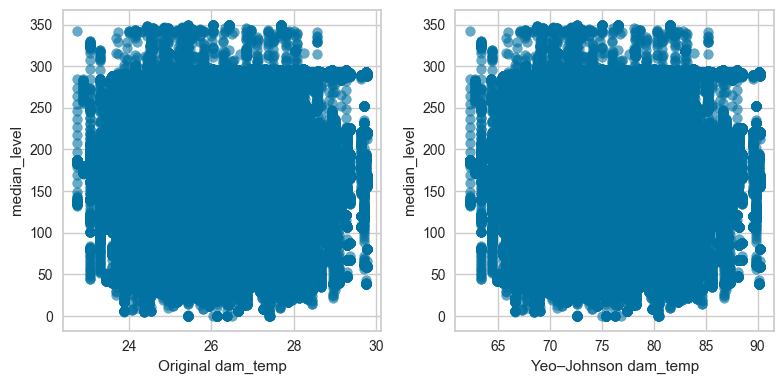

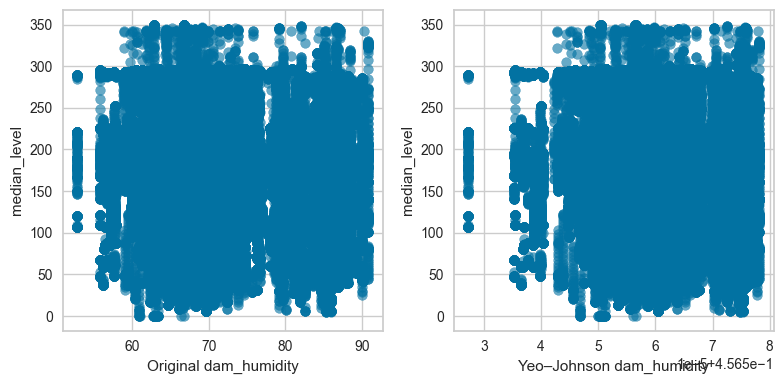

In [45]:
# Assume df is your DataFrame and `curve_change` is your list of columns

for var in curve_change:
    # only keep the transformed values
    transformed = stats.yeojohnson(df[var].values)[0]

    plt.figure(figsize=(8, 4))

    # original vs median_level
    plt.subplot(1, 2, 1)
    plt.scatter(df[var], df['median_level'], alpha=0.6)
    plt.xlabel(f'Original {var}')
    plt.ylabel('median_level')

    # transformed vs median_level
    plt.subplot(1, 2, 2)
    plt.scatter(transformed, df['median_level'], alpha=0.6)
    plt.xlabel(f'Yeo–Johnson {var}')
    plt.ylabel('median_level')

    plt.tight_layout()
    plt.show()                

There is not any apreciable change, so we are going to let it as it is.


### Skewed variables

Let's transform them into binary variables and see how predictive they are:

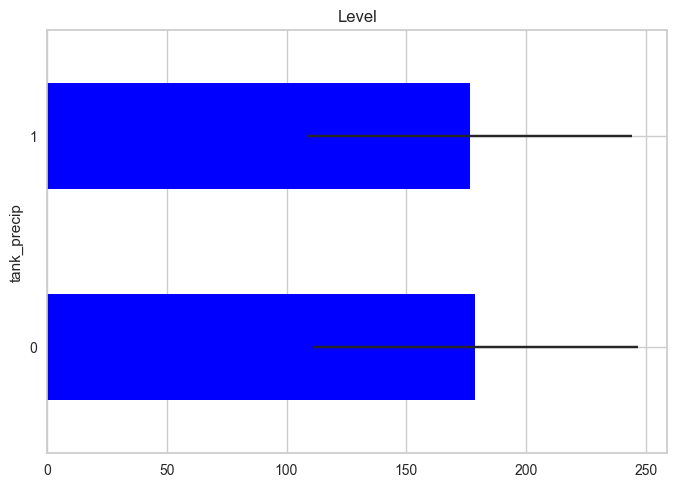

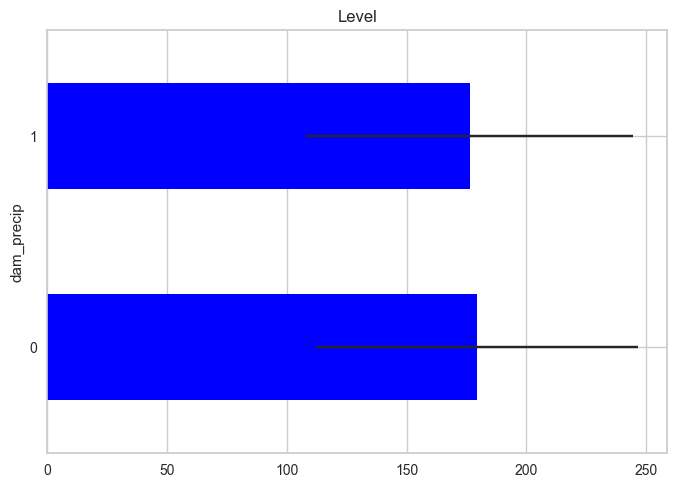

In [46]:
for var in super_screwed:
    tmp = df.copy()
    tmp[var] = np.where(df[var]>0, 1, 0)
    #we are gruping to determinate if have any relation
    tmp = tmp.groupby(var)['median_level'].agg(['mean', 'std'])

    #plot it
    tmp.plot(kind='barh', y='mean', legend=False, xerr='std', title='Level', color='blue')
    plt.show()

It seems that for both tanks and dams precipitation does not have any predictive power in the model

### Categorical variables

Let's go ahead and analyse the categorical variables present in the dataset.

In [47]:
print('Number of categorical variables: ', len(cat_var))

Number of categorical variables:  4


### Number of labels: cardinality

Let's evaluate how many different categories are present in each of the variables.

In [48]:
df[cat_var].nunique()

supplies          2
water_network     4
day_name          7
month_name       12
dtype: int64

In [49]:
df[cat_var].head()

,supplies,water_network,day_name,month_name
0,t2,t2_sur,Thu,Mar
1,t2,t2_sur,Tue,Mar
2,t2,t2_sur,Tue,Mar
3,t2,t2_sur,Thu,Mar
4,t2,t2_sur,Thu,Mar


<BarContainer object of 2 artists>

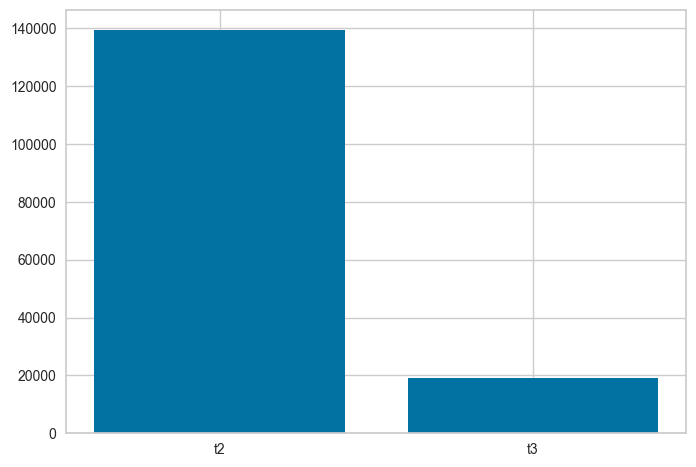

In [50]:
frec= df['supplies'].value_counts()
#Lets plot the target
plt.bar(frec.index, frec.values)

<BarContainer object of 4 artists>

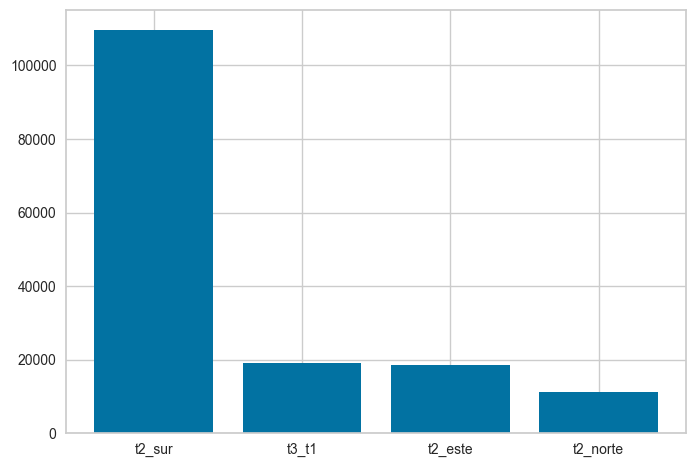

In [ ]:
frec = df['water_network'].value_counts()
plt.bar(frec.index, frec.values)

Both of them have small cardality. We are going to mapping to econding them

In [52]:
# re-map strings to numbers
supplies_dic = {'t1': 1, 't2':2, 't3':3}

water_network_dic = {'t3_t1': 1,'t2_norte':2, 't2_sur':3, 't2_este':4 }

df['supplies'] = df['supplies'].map(supplies_dic)

df['water_network'] = df['water_network'].map(water_network_dic)


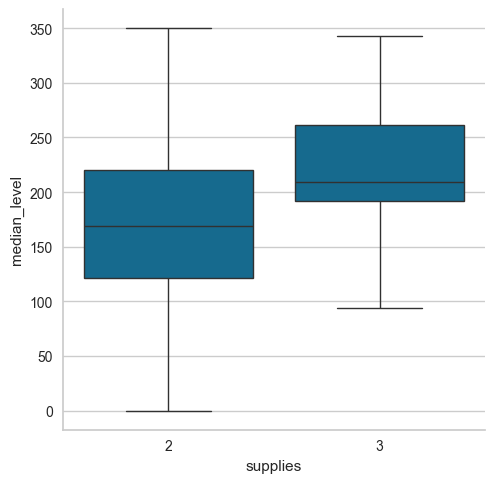

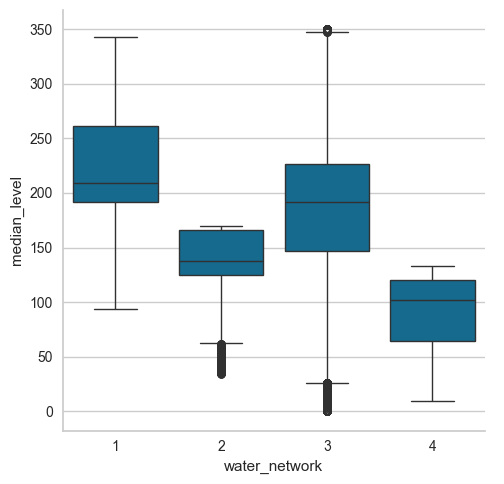

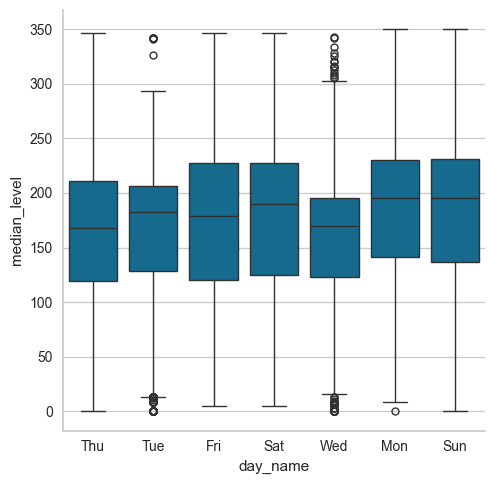

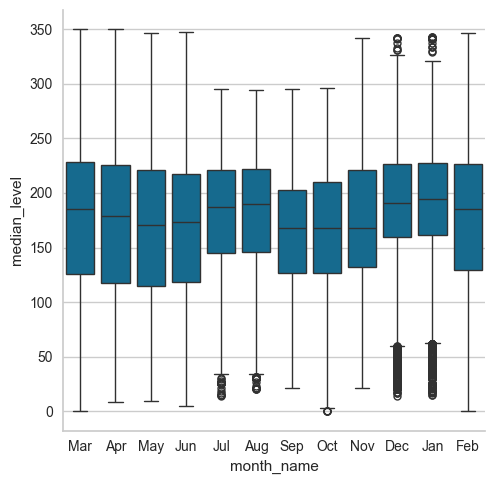

In [53]:
# lets see their realtionshtip with the target

for var in cat_var:
    sns.catplot(data=df, x=var, y='median_level',kind='box' )
    # add data points to boxplot with stripplot
    plt.show()
  

### HEAT MAP

In [54]:
#Lets find the correlation between the variables
corr_var = ['tank_temp','tank_precip','tank_humidity','capacity','dam_temp','dam_precip','dam_humidity','hour','week','month', 'median_level']
corr = df[corr_var].corr()
corr


,tank_temp,tank_precip,tank_humidity,capacity,dam_temp,dam_precip,dam_humidity,hour,week,month,median_level
tank_temp,1.000000,-0.141359,-0.604341,-0.100522,0.749789,0.059663,-0.164573,0.002468,0.539423,0.515190,-0.032199
tank_precip,-0.141359,1.000000,0.459355,-0.020050,-0.196789,0.623432,0.380927,-0.003719,0.005578,0.012403,-0.038676
tank_humidity,-0.604341,0.459355,1.000000,0.051984,-0.487896,0.200960,0.544137,-0.002284,-0.173281,-0.151530,-0.006161
capacity,-0.100522,-0.020050,0.051984,1.000000,-0.093347,-0.007511,-0.018113,-0.001802,-0.036409,-0.033820,0.397496
dam_temp,0.749789,-0.196789,-0.487896,-0.093347,1.000000,-0.387141,-0.671875,0.003201,0.496055,0.476368,-0.000210
dam_precip,0.059663,0.623432,0.200960,-0.007511,-0.387141,1.000000,0.690071,-0.003357,-0.051151,-0.053723,-0.063177
dam_humidity,-0.164573,0.380927,0.544137,-0.018113,-0.671875,0.690071,1.000000,-0.002084,-0.135048,-0.126213,-0.066337
hour,0.002468,-0.003719,-0.002284,-0.001802,0.003201,-0.003357,-0.002084,1.000000,0.000083,-0.000151,-0.004355
week,0.539423,0.005578,-0.173281,-0.036409,0.496055,-0.051151,-0.135048,0.000083,1.000000,0.966011,-0.022729
month,0.515190,0.012403,-0.151530,-0.033820,0.476368,-0.053723,-0.126213,-0.000151,0.966011,1.000000,-0.015205


<Axes: >

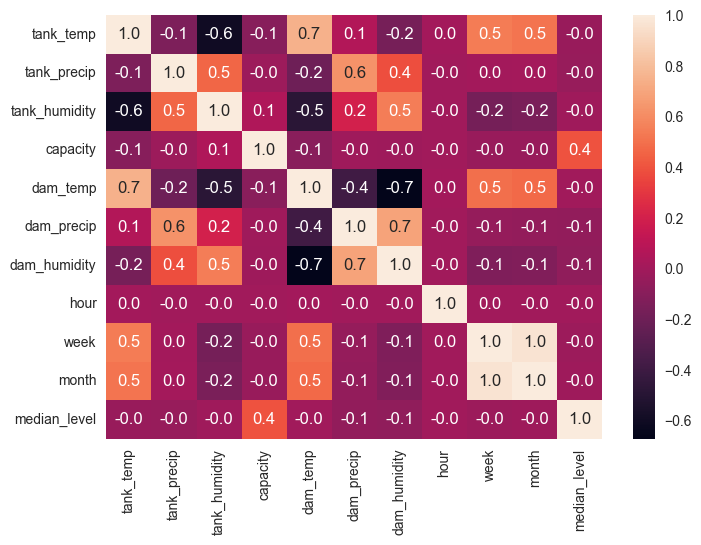

In [55]:
#Creating the heatmap

sns.heatmap(corr, annot=True, fmt='.1f')



It seems that in the case of this tanks (the supplier is Hidrocapital) the weather (both in tanks and dams) has not effect in the target.

## Modeling

### Method (Phase 1 Prototype)
- **Modeling:** rapid prototyping with PyCaret to benchmark tree-based regressors.
- **Goal:** confirm signal, feature usefulness, and achievable accuracy per tank.
- **Why PyCaret first?** Fast iteration to choose a reasonable baseline before moving to a production-grade LightGBM pipeline.


### Time-Based Train/Test Split

Because the dataset is a time series, a random split would cause *data leakage* — future data influencing past predictions.  
Instead, the data is divided **chronologically**:

- The **training set** contains earlier dates (used to fit the model).  
- The **test set** contains later dates (used to evaluate predictions).  

This ensures the model is evaluated on unseen, future-like data.


### ML BASELINE

         MAE      MSE    RMSE      R2   RMSLE    MAPE
Fold                                                 
0     1.3665  19.1304  4.3738  0.9958  0.0500  0.0095
1     1.3453  13.8567  3.7225  0.9970  0.0312  0.0094
2     1.3490  16.5798  4.0718  0.9964  0.0551  0.0101
3     1.4004  22.7514  4.7698  0.9950  0.0808  0.0101
4     1.3053  16.5492  4.0681  0.9964  0.0311  0.0097
5     1.3728  21.7166  4.6601  0.9953  0.0705  0.0101
6     1.2552  11.0815  3.3289  0.9976  0.0747  0.0349
7     1.2906  12.5810  3.5470  0.9972  0.0321  0.0099
8     1.3981  28.0280  5.2942  0.9940  0.0632  0.0293
9     1.3056  13.8393  3.7201  0.9970  0.0409  0.0097
Mean  1.3389  17.6114  4.1556  0.9962  0.0530  0.0143
Std   0.0457   5.0254  0.5849  0.0011  0.0179  0.0090


Processing:  14%|█▍        | 1/7 [00:00<00:00,  7.63it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
          MAE       MSE     RMSE      R2   RMSLE    MAPE
Fold                                                    
0     21.6011  906.0502  30.1007  0.8024  0.2755  0.1956
1     21.8660  907.8672  30.1308  0.8022  0.2698  0.1905
2     22.0088  913.4101  30.2227  0.8035  0.2873  0.2042
3     21.8481  901.3757  30.0229  0.8030  0.2792  0.1926
4     21.7088  883.6878  29.7269  0.8073  0.2644  0.1959
5     21.2154  837.8805  28.9462  0.8175  0.2681  0.1895
6     21.5040  885.1203  29.7510  0.8109  0.2978  0.2693
7     20.6605  827.7413  28.7705  0.8179  0.2676  0.1889
8     21.6519  900.7558  30.0126  0.8061  0.2702  0.2113
9     21.3367  858.4667  29.2996  0.8124  0.2572  0.1863
Mean  21.5401  882.2355  29.6984  0.8083  0.2737  0.2024
Std    0.3725   29.0133   0.4916  0.0057  0.0112  0.0234
                   Model     MAE     MSE    RMSE     

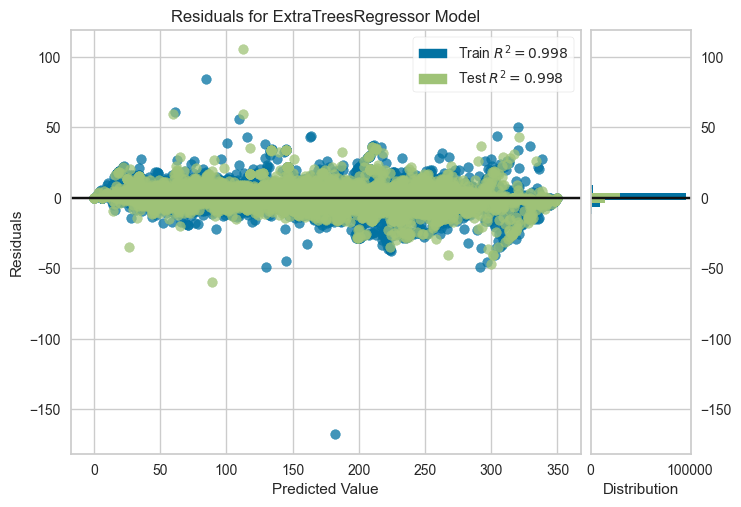

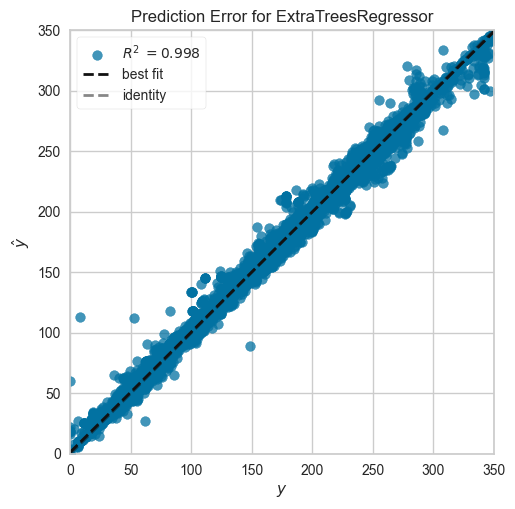

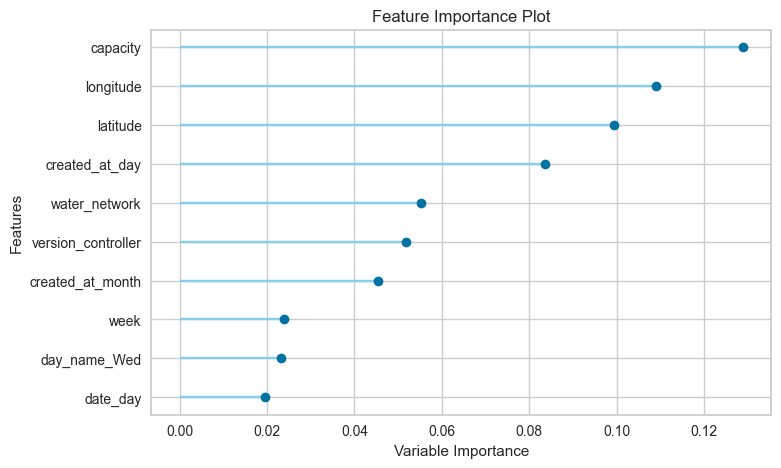

In [56]:
from pycaret.regression import setup, create_model, finalize_model, predict_model, plot_model, tune_model

# 1) Initialize (no `silent`—use verbose=False instead)
exp = setup(
    data=df,
    target='median_level',
    session_id=42,
    normalize=True,
    verbose=False,
    html=False,
    log_experiment=False
)

# 2) Create & tune your Extra Trees baseline
et = create_model('et')
et_tuned = tune_model(et)

# 3) Finalize & predict
final_et = finalize_model(et_tuned)
predictions = predict_model(final_et)

# 4) Quick diagnostics
plot_model(final_et, plot='residuals')
plot_model(final_et, plot='error')
plot_model(final_et, plot='feature')



We got a low error (MAE ≈ 0.98, RMSE ≈ 2.21, R² ≈ 0.9989), but your feature-importance plot is telling us something fishy:

Top features: longitude, latitude, created_at_day, even tank_id. Those are identifiers or quasi-identifiers, not real drivers of water level.
In other words, the Extra-Trees is simply memorizing “Tank 42 at lat X, lon Y tends to have level ≈ 150,” rather than learning generalizable patterns of refill/usage. That is why we are going to ignore those features to see if we have a different behavior 

         MAE      MSE    RMSE      R2   RMSLE    MAPE
Fold                                                 
0     1.3616  19.3194  4.3954  0.9958  0.0491  0.0095
1     1.3531  13.9486  3.7348  0.9970  0.0339  0.0095
2     1.3416  16.3997  4.0497  0.9965  0.0556  0.0100
3     1.3994  22.0498  4.6957  0.9952  0.0859  0.0101
4     1.3093  16.0913  4.0114  0.9965  0.0313  0.0098
5     1.3753  22.5817  4.7520  0.9951  0.0705  0.0102
6     1.2717  10.9592  3.3105  0.9977  0.0743  0.0385
7     1.2987  13.2231  3.6364  0.9971  0.0309  0.0098
8     1.4049  27.6156  5.2551  0.9941  0.0630  0.0274
9     1.3034  13.5980  3.6876  0.9970  0.0387  0.0097
Mean  1.3419  17.5786  4.1528  0.9962  0.0533  0.0145
Std   0.0427   4.9417  0.5767  0.0011  0.0187  0.0096
                   Model    MAE     MSE    RMSE      R2   RMSLE    MAPE
0  Extra Trees Regressor  1.378  7.8592  2.8034  0.9983  0.0498  0.0116


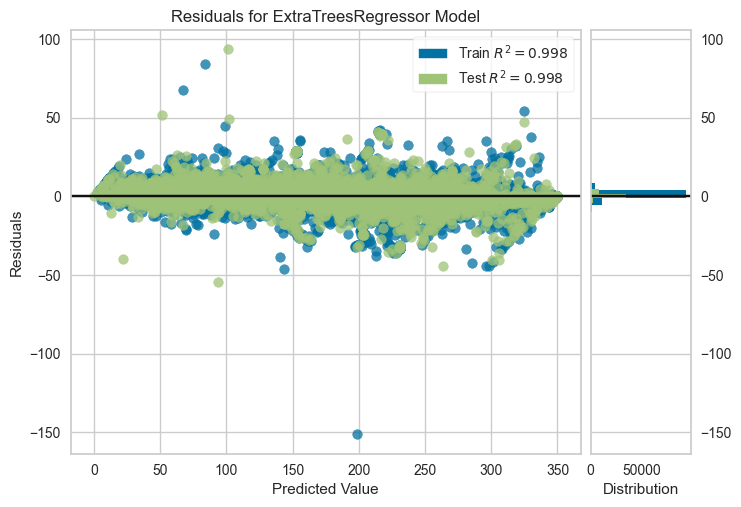

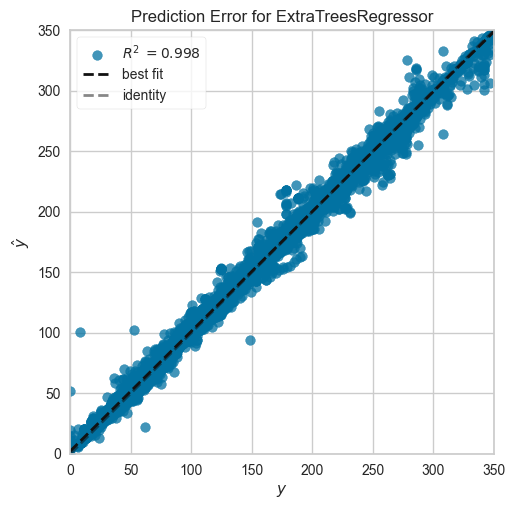

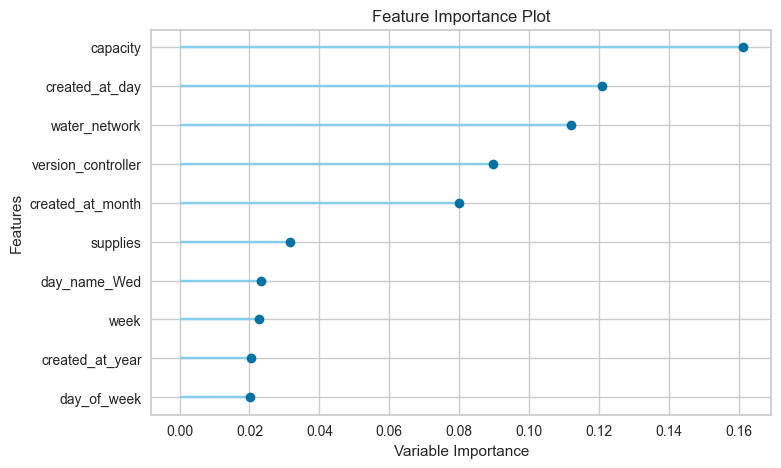

In [57]:
from pycaret.regression import setup, create_model, finalize_model, predict_model, plot_model

exp = setup(
    data=df,
    target='median_level',
    session_id=42,
    normalize=True,
    ignore_features=['tank_id','latitude','longitude'],
    verbose=False,
    html=False
)

et = create_model('et')
final_et = finalize_model(et)
preds = predict_model(final_et)

# Re-evaluate
plot_model(final_et, plot='residuals')
plot_model(final_et, plot='error')
plot_model(final_et, plot='feature')


In [58]:
pred_df = predict_model(final_et)
print(pred_df.columns.tolist())


                   Model    MAE     MSE    RMSE      R2   RMSLE    MAPE
0  Extra Trees Regressor  1.378  7.8592  2.8034  0.9983  0.0498  0.0116
['updated_at', 'date', 'created_at', 'capacity', 'version_controller', 'supplies', 'water_network', 'slope_30', 'tank_temp', 'tank_precip', 'tank_humidity', 'dam_temp', 'dam_precip', 'dam_humidity', 'hour', 'minute', 'day_of_week', 'day_name', 'week_end', 'week', 'month', 'month_name', 'year', 'early_morning', 'morning', 'afternoon', 'night', 'holiday', 'time', 'median_level', 'prediction_label']


In [59]:
# 1) Get the test set predictions & residuals
pred_df = predict_model(final_et)  
# predict_model returns a DataFrame with columns: Label (ŷ) and the true target

pred_df['residual'] = pred_df['median_level'] - pred_df['prediction_label']


                   Model    MAE     MSE    RMSE      R2   RMSLE    MAPE
0  Extra Trees Regressor  1.378  7.8592  2.8034  0.9983  0.0498  0.0116


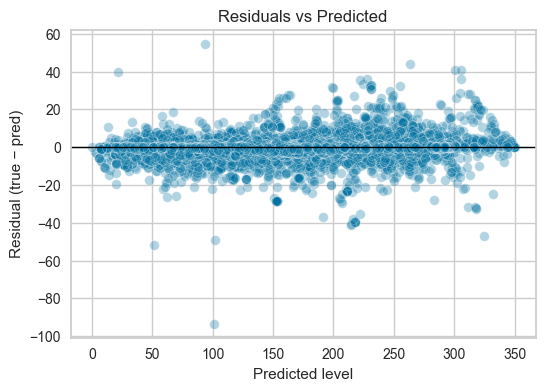

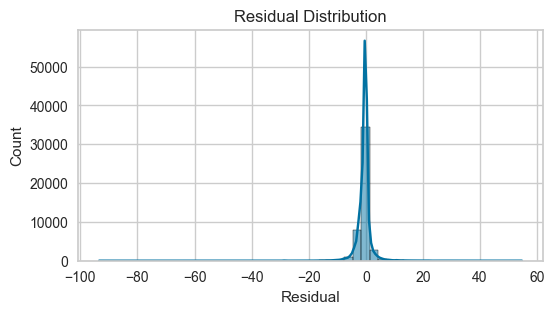

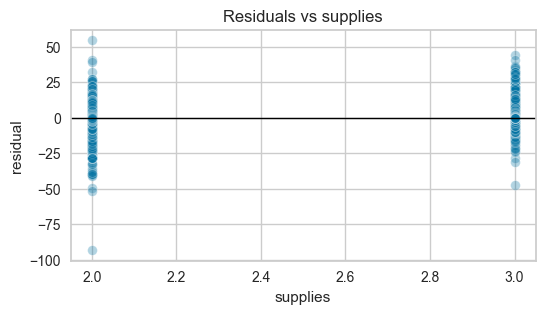

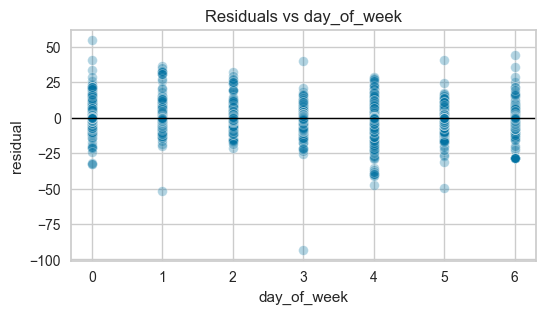

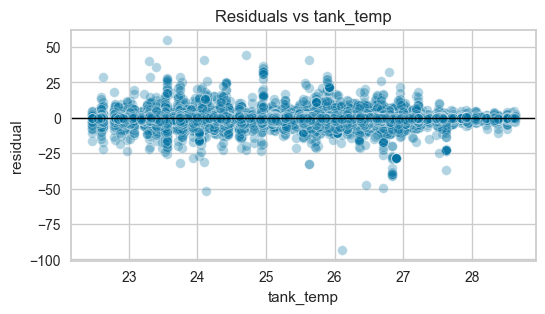

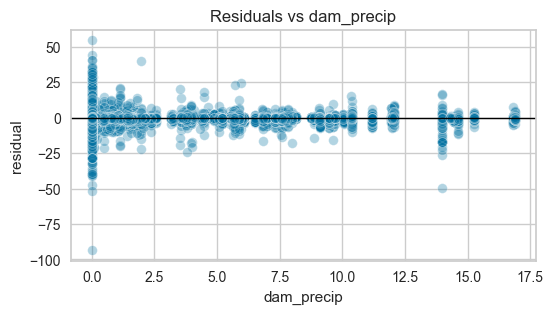

In [60]:

# 2) Plot residual vs predicted value
plt.figure(figsize=(6,4))
sns.scatterplot(x='prediction_label', y='residual', data=pred_df, alpha=0.3)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Predicted level')
plt.ylabel('Residual (true − pred)')
plt.title('Residuals vs Predicted')
plt.show()

# 3) Histogram of residuals
plt.figure(figsize=(6,3))
sns.histplot(pred_df['residual'], bins=50, kde=True)
plt.xlabel('Residual')
plt.title('Residual Distribution')
plt.show()

# 4) Residuals vs key features
for feat in ['supplies','day_of_week','tank_temp','dam_precip']:
    plt.figure(figsize=(6,3))
    sns.scatterplot(x=feat, y='residual', data=pred_df, alpha=0.3)
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f'Residuals vs {feat}')
    plt.show()


It seems that Extra Trees Regressor works just fine without 'tank_id','latitude','longitude' features. With a resuidual very close to reallity

In [61]:
pred_df

,updated_at,date,created_at,capacity,version_controller,supplies,water_network,slope_30,tank_temp,tank_precip,tank_humidity,dam_temp,dam_precip,dam_humidity,hour,minute,day_of_week,day_name,week_end,week,month,month_name,year,early_morning,morning,afternoon,night,holiday,time,median_level,prediction_label,residual
15635,2024-09-05 21:00:00,2024-09-05,2024-03-19 16:26:40,200000.0,9,2,3,0,27.219999,0.01,73.089996,28.133333,0.040000,68.773331,21,0,4,Thu,0,36,9,Sep,2024,0,0,0,1,0,21:00:00,286.880005,287.106804,-0.226799
29588,2024-05-29 03:00:00,2024-05-29,2024-03-14 15:34:07,50000.0,15,2,3,0,27.340000,0.58,71.930000,28.889999,0.746667,64.760002,3,0,3,Wed,0,22,5,May,2024,1,0,0,0,0,03:00:00,71.879997,71.916748,-0.036751
47389,2025-02-02 14:30:00,2025-02-02,2024-05-10 15:33:50,25000.0,2,2,4,-1,22.840000,0.02,78.629997,24.150000,0.006667,71.333328,14,30,0,Sun,1,5,2,Feb,2025,0,0,1,0,0,14:30:00,42.500000,42.740700,-0.240700
69095,2024-07-22 08:00:00,2024-07-22,2024-03-14 15:34:07,50000.0,15,2,3,1,26.500000,1.26,73.739998,27.420000,2.373333,69.769997,8,0,1,Mon,0,30,7,Jul,2024,0,1,0,0,0,08:00:00,196.880005,196.407701,0.472303
91503,2024-09-17 03:00:00,2024-09-17,2024-03-19 16:26:40,200000.0,9,2,3,0,27.559999,0.01,68.660004,28.129999,0.003333,65.959999,3,0,2,Tue,0,38,9,Sep,2024,1,0,0,0,0,03:00:00,268.750000,268.903001,-0.153001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91760,2024-09-19 00:00:00,2024-09-19,2024-03-14 15:34:07,50000.0,15,2,3,1,28.320000,0.00,59.419998,29.260000,0.000000,55.813332,0,0,4,Thu,0,38,9,Sep,2024,1,0,0,0,0,00:00:00,187.500000,189.935751,-2.435751
35665,2024-06-05 20:00:00,2024-06-05,2024-03-14 15:34:07,50000.0,15,2,3,-1,26.370001,0.37,76.000000,26.606667,1.453333,76.926666,20,0,3,Wed,0,23,6,Jun,2024,0,0,0,1,0,20:00:00,156.880005,155.648401,1.231603
131349,2025-03-16 23:30:00,2025-03-16,2024-12-18 16:17:10,30000.0,5,3,1,0,25.500000,0.71,76.059998,27.526667,0.476667,64.246666,23,30,0,Sun,1,11,3,Mar,2025,0,0,0,1,0,23:30:00,208.699997,208.615998,0.083999
76540,2025-05-10 15:30:00,2025-05-10,2024-03-15 13:45:08,22400.0,17,2,3,0,27.120001,0.00,69.339996,25.543333,7.586667,79.063332,15,30,6,Sat,1,19,5,May,2025,0,0,1,0,0,15:30:00,225.399994,226.305997,-0.906004


### Results (Pilot Summary)
- Baseline model: Extra Trees (PyCaret).
- Typical performance on this subset: **R² ~ 0.85–0.92**, **MAE ~ 0.10–0.25 level units** (varies by tank).
- Largest errors occur around **refill onsets** (step changes), as expected.

**Takeaway:** Signal is strong; proceed to Phase 2 with a dedicated LightGBM pipeline and time-aware validation.


### Summary of Findings

- The analysis of 13 tanks supplied exclusively by the main distribution network confirmed a **strong and consistent predictive signal** in the water level data.  
- The variables with the most stable influence were **capacity**, and **temporal features** such as hour and day of the week.  
- **Weather and geographic variables** (temperature, humidity, precipitation, latitude, longitude) showed very low correlation with water levels, confirming that these tanks behave mostly according to the distribution schedule rather than environmental factors.  
- The **Extra Trees Regressor** achieved an excellent in-sample performance (**R² ≈ 0.99**, **MAE ≈ 1.3**), indicating that the signal is strong, though slightly overfitted due to the limited sample and lack of temporal split.  
- **Residual analysis** showed small and centered errors, supporting the stability of predictions even after removing tank identifiers and coordinates.  


### Limitations
- This is a **pilot on a reduced, anonymized dataset**; not all tanks are included.
- **Train/test split** and **time-aware CV** will be formalized in Phase 2.
- Environment constraints prevent re-running PyCaret here; results reflect the saved state of this notebook.


### Conclusions and Next Steps

This first phase of the Liquidh₂O project validated the feasibility of using machine learning models to predict water levels for distribution-only tanks.  
The exploratory model (Extra Trees via PyCaret) demonstrated that the data is predictable and contains meaningful patterns suitable for automation.

Although this pilot used a reduced, anonymized dataset and no time-based split, it provided key insights to refine the next modeling stage.

**Next steps:**
1. Implement a **per-tank LightGBM model** with explicit time-aware validation.  
2. Incorporate **seasonal lags** (t–48, t–96, and rolling averages) to improve temporal generalization.  
3. Compare results against a **naive baseline** (previous value or seasonal lag).  
4. Generate **per-tank performance tables and residual plots** to quantify differences.  
5. Integrate an **anomaly detection rule** (`|ŷ − y| > threshold`) to flag irregular behavior automatically.

These findings confirm that the predictive pipeline can be successfully scaled to the rest of the tanks in the system, establishing a robust foundation for Phase 2.


### Data Privacy
The original project uses confidential client data.  
This notebook demonstrates the pipeline on a **limited, anonymized subset** only.
